Stationary distribution:  π₀ = 0.5714,  π₁ = 0.4286


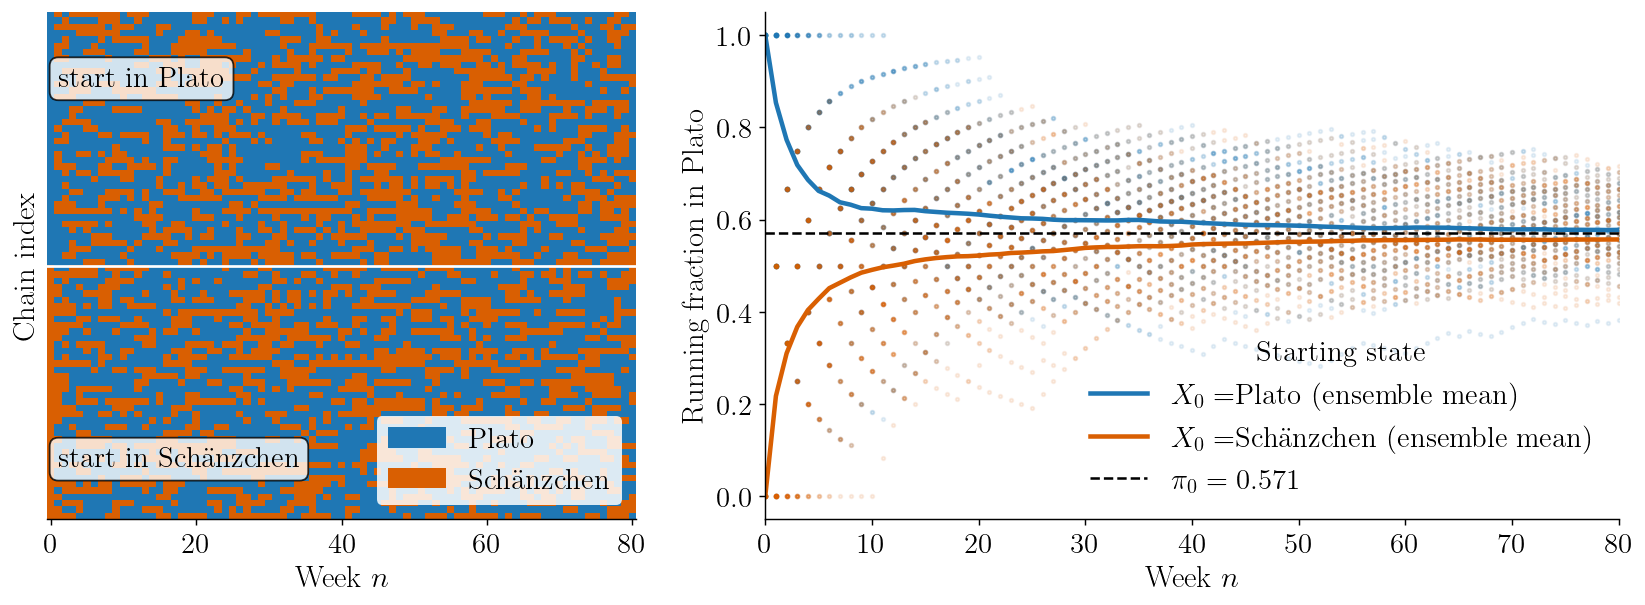

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         18,
    'axes.titlesize':    17,
    'axes.labelsize':    17,
    'xtick.labelsize':   16,
    'ytick.labelsize':   16,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})

T = np.array([[0.7, 0.3],
              [0.4, 0.6]])

pi_stat = np.array([T[1, 0], T[0, 1]]) / (T[0, 1] + T[1, 0])
print(f"Stationary distribution:  π₀ = {pi_stat[0]:.4f},  π₁ = {pi_stat[1]:.4f}")

rng      = np.random.default_rng(42)
N_chains = 400
N_steps  = 80

def simulate_chains(T, n_chains, n_steps, start, rng):
    """Vectorised: n_chains independent Markov chains all starting in state `start`."""
    state         = np.full(n_chains, start, dtype=int)
    seq           = np.empty((n_chains, n_steps + 1), dtype=int)
    seq[:, 0]     = state
    for step in range(n_steps):
        u                  = rng.uniform(size=n_chains)
        state              = (u >= T[state, 0]).astype(int)
        seq[:, step + 1]   = state
    return seq

seqs_0 = simulate_chains(T, N_chains, N_steps, start=0, rng=rng)
seqs_1 = simulate_chains(T, N_chains, N_steps, start=1, rng=rng)
steps  = np.arange(N_steps + 1)

# Running fraction of steps spent in state 0 up to step n:
run_0 = (seqs_0 == 0).cumsum(axis=1) / (steps + 1)
run_1 = (seqs_1 == 0).cumsum(axis=1) / (steps + 1)

n_raster = 40    
n_lines  = 50   

C0, C1 = '#1f77b4', '#d95f02'

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw=dict(width_ratios=[1, 1.45]))

ax     = axes[0]
cmap2  = ListedColormap([C0, C1])
raster = np.vstack([seqs_0[:n_raster], seqs_1[:n_raster]])
ax.imshow(raster, aspect='auto', interpolation='nearest', cmap=cmap2, vmin=0, vmax=1)
ax.axhline(n_raster - 0.5, color='white', lw=1.5)
ax.set_xlabel(r'Week $n$')
ax.set_ylabel('Chain index')
ax.text(1, n_raster * 0.25, r'start in Plato', fontsize=16,
        color='black', fontweight='bold', va='center',
        bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="black",
        alpha=0.8))
ax.text(1, n_raster * 1.75, r'start in Schänzchen', fontsize=16,
        color='black', fontweight='bold', va='center',
        bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="black",
        alpha=0.8))
ax.tick_params(axis='y', left=False, labelleft=False)
ax.spines['left'].set_visible(False)
ax.legend(handles=[Patch(facecolor=C0, label='Plato'),
                   Patch(facecolor=C1, label='Schänzchen')],
          loc='lower right', fontsize=16,
          frameon=True, framealpha=0.85, edgecolor='none')

ax2 = axes[1]

for run in run_0[:n_lines]:
    ax2.plot(steps, run, color=C0, alpha=0.10, lw=0.7, ls = "", marker="o", markersize=2)
for run in run_1[:n_lines]:
    ax2.plot(steps, run, color=C1, alpha=0.10, lw=0.7, ls = "", marker="o", markersize=2)

ax2.plot(steps, run_0.mean(axis=0), color=C0, lw=2.5,
         label=r'$X_0 = $Plato (ensemble mean)')
ax2.plot(steps, run_1.mean(axis=0), color=C1, lw=2.5,
         label=r'$X_0 = $Schänzchen (ensemble mean)')
ax2.axhline(pi_stat[0], color='k', lw=1.4, ls='--',
            label=rf'$\pi_0 = {pi_stat[0]:.3f}$')

ax2.set_xlabel(r'Week $n$')
ax2.set_ylabel(r'Running fraction in Plato')
ax2.set_xlim(0, N_steps)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(title='Starting state', fontsize=16, title_fontsize=16)

plt.tight_layout()
plt.savefig('6_plots_markov_convergence.pdf', bbox_inches='tight')
plt.show()


## MCMC example: fitting an H$\alpha$ emission line

We model a continuum-subtracted stellar emission line as a Gaussian with three free parameters:

$$
f(\lambda\mid A,\,\lambda_0,\,\sigma)
= A\,\exp\!\left(-\frac{(\lambda-\lambda_0)^2}{2\sigma^2}\right)
$$

| Parameter | Symbol | Physical meaning |
|-----------|--------|-----------------|
| Amplitude | $A$ | peak normalised flux |
| Central wavelength | $\lambda_0$ | line centre [Å] |
| Line width | $\sigma$ | Gaussian $\sigma$ [Å] |

We generate a synthetic spectrum of H$\alpha$ ($\lambda_0 = 6563\,\text{Å}$) with Gaussian photon noise and recover the parameters with `emcee`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# ── True parameters ────────────────────────────────────────────────────────────
A_true      = 1.0      # peak normalised flux
lam0_true   = 6563.0   # Hα rest wavelength [Å]
sigma_true  = 5.0      # line width [Å]
sigma_noise = 0.05     # per-pixel noise [normalised flux]

# ── Synthetic spectrum ─────────────────────────────────────────────────────────
rng        = np.random.default_rng(42)
wavelength = np.linspace(6530, 6600, 80)
flux_true  = A_true * np.exp(-0.5 * ((wavelength - lam0_true) / sigma_true)**2)
flux_obs   = flux_true + rng.normal(0.0, sigma_noise, len(wavelength))

# ── Model and log-probability ──────────────────────────────────────────────────
def model(lam, A, lam0, sigma):
    return A * np.exp(-0.5 * ((lam - lam0) / sigma)**2)

def log_likelihood(theta, lam, flux, noise):
    A, lam0, sigma = theta
    return -0.5 * np.sum(((flux - model(lam, A, lam0, sigma)) / noise)**2)

def log_prior(theta):
    A, lam0, sigma = theta
    if 0.0 < A < 5.0 and 6540.0 < lam0 < 6590.0 and 0.5 < sigma < 30.0:
        return 0.0
    return -np.inf

def log_posterior(theta, lam, flux, noise):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, lam, flux, noise) if np.isfinite(lp) else -np.inf

# ── Initialise walkers near the truth ─────────────────────────────────────────
ndim, nwalkers = 3, 32
p0_true    = np.array([A_true, lam0_true, sigma_true])
p0_walkers = p0_true + 1e-3 * rng.standard_normal((nwalkers, ndim))

# ── Run MCMC ──────────────────────────────────────────────────────────────────
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
    args=(wavelength, flux_obs, sigma_noise),
)
sampler.run_mcmc(p0_walkers, 3000, progress=True)

flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)
print(f"\nChain shape: {flat_samples.shape}")

labels    = [r"$A$", r"$\lambda_0\;[\AA]$", r"$\sigma\;[\AA]$"]
true_vals = [A_true, lam0_true, sigma_true]
for i, (lbl, tv) in enumerate(zip(labels, true_vals)):
    med = np.median(flat_samples[:, i])
    std = flat_samples[:, i].std()
    print(f"  {lbl:25s}  median = {med:.4f}  std = {std:.4f}  (true: {tv})")

chain = sampler.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)
for i, (ax, lbl, tv) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(chain[:, :, i], color="k", alpha=0.25, lw=0.5)
    ax.axvline(500, color="C3", lw=1.2, ls="--", label="burn-in cut" if i == 0 else "")
    ax.axhline(tv,  color="C1", lw=1.5, label="true value" if i == 0 else "")
    ax.set_ylabel(lbl)
axes[0].legend(fontsize=10)
axes[-1].set_xlabel("Step")
fig.suptitle(r"MCMC traces — H$\alpha$ line fit", fontsize=13)
plt.tight_layout()
plt.show()

lam_fine = np.linspace(wavelength.min(), wavelength.max(), 500)
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(wavelength, flux_obs, yerr=sigma_noise,
            fmt=".", color="C0", alpha=0.7, label="Synthetic data")
draw_idx = rng.integers(0, len(flat_samples), 200)
for theta in flat_samples[draw_idx]:
    ax.plot(lam_fine, model(lam_fine, *theta), color="C1", alpha=0.04, lw=0.8)
ax.plot(lam_fine, model(lam_fine, *true_vals), "k", lw=2, label="True model")
ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Normalised flux")
ax.set_title(r"H$\alpha$ emission line — posterior predictive")
ax.legend()
plt.tight_layout()
plt.show()

fig = corner.corner(
    flat_samples, labels=labels, truths=true_vals,
    quantiles=[0.16, 0.5, 0.84], show_titles=True,
    title_kwargs={"fontsize": 11},
)
fig.suptitle(r"Posterior — H$\alpha$ line fit", y=1.02, fontsize=13)
plt.show()

In [ ]:
from scipy.stats import multivariate_normal

# 2D correlated Gaussian
mu    = np.array([0.0, 0.0])
rho   = 0.7                        # correlation coefficient
sigma = np.array([1.0, 2.0])       # per-axis standard deviations
Sigma = np.array([[sigma[0]**2,              rho*sigma[0]*sigma[1]],
                  [rho*sigma[0]*sigma[1],    sigma[1]**2           ]])

# Draw samples and evaluate log-likelihood
rng      = np.random.default_rng(42)
samples  = rng.multivariate_normal(mu, Sigma, size=2000)
log_like = multivariate_normal.logpdf(samples, mean=mu, cov=Sigma)

# Sort descending: highest log-likelihood first
sort_idx = np.argsort(log_like)[::-1]
samples  = samples[sort_idx]
log_like = log_like[sort_idx]

print(f"samples shape : {samples.shape}")
print(f"log L  range  : [{log_like[-1]:.2f}, {log_like[0]:.2f}]")

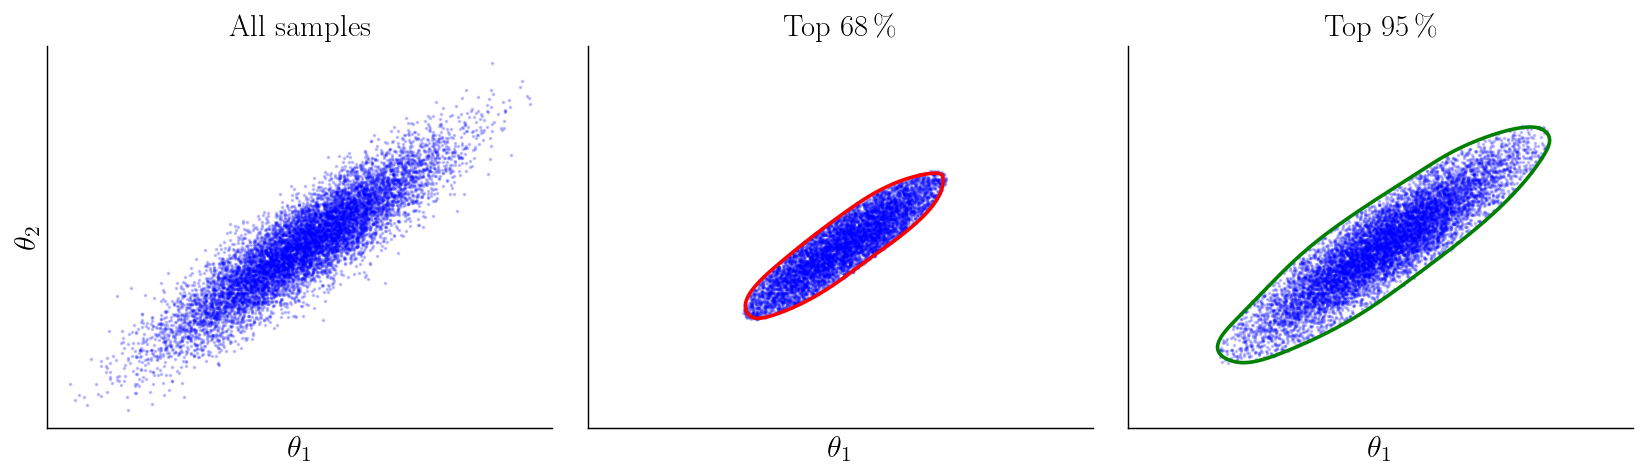

In [ ]:
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev
from scipy.stats import gaussian_kde

index68 = int(len(samples) * 0.68)
index95 = int(len(samples) * 0.95)

def plot_hull(ax, pts, **kwargs):
    hull      = ConvexHull(pts)
    hp        = pts[hull.vertices]
    x         = np.r_[hp[:, 0], hp[0, 0]]
    y         = np.r_[hp[:, 1], hp[0, 1]]
    k         = min(3, len(hp) - 1)
    tck, _    = splprep([x, y], s=0.1, per=True, k=k)
    xs, ys    = splev(np.linspace(0, 1, 400), tck)
    ax.plot(xs, ys, **kwargs)

# Fit KDE once on all samples; derive levels from the full distribution
kde_all    = gaussian_kde(samples.T)
z_all      = kde_all(samples.T)
level_68   = np.percentile(z_all, 32)   # encloses 68 % of all samples
level_95   = np.percentile(z_all,  5)   # encloses 95 % of all samples

def add_kde(ax, levels, **kwargs):
    """Draw KDE contour lines on a grid using the shared kde_all."""
    xg     = np.linspace(samples[:, 0].min(), samples[:, 0].max(), 300)
    yg     = np.linspace(samples[:, 1].min(), samples[:, 1].max(), 300)
    xx, yy = np.meshgrid(xg, yg)
    zz     = kde_all(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=sorted(levels), **kwargs)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)

axes[0].scatter(samples[:, 0],        samples[:, 1],        color="blue",  alpha=0.2, s=1)
axes[0].set_title("All samples")

axes[1].scatter(samples[:index68, 0], samples[:index68, 1], color="blue",   alpha=0.2, s=1)
plot_hull(axes[1], samples[:index68, 0:2], color="red",   lw=2)
axes[1].set_title(r"Top 68\,\%")

axes[2].scatter(samples[:index95, 0], samples[:index95, 1], color="blue", alpha=0.2, s=1)
plot_hull(axes[2], samples[:index95, 0:2], color="red", lw=2)


want_kde = False
if want_kde:
    add_kde(axes[1], [level_68],               colors='red',   linewidths=1.5, linestyles='--')
    add_kde(axes[0], [level_95, level_68], colors='k', linewidths=(1.0, 1.5))
    add_kde(axes[2], [level_95],               colors='red', linewidths=1.5, linestyles='--')
axes[2].set_title(r"Top 95\,\%")

for ax in axes:
    ax.set_xlabel(r'$\theta_1$')
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].set_ylabel(r'$\theta_2$')

plt.tight_layout()
plt.savefig('6_plots_mcmc_hulls.pdf', bbox_inches='tight')
plt.show()